## Face Recognition For The Happy House
Face recognition commonly fall into 2 categories
1. Face Verification:  "is this the claimed person?". For example, at some airports, you can pass through customs by letting a system scan your passport and then verifying that you (the person carrying the passport) are the correct person. A mobile phone that unlocks using your face is also using face verification. This is a 1:1 matching problem.
2.Face Recognition - "who is this person?". For example, the video lecture showed a face recognition [video](https://www.youtube.com/watch?v=wr4rx0Spihs) of Baidu employees entering the office without needing to otherwise identify themselves. This is a 1:K matching problem.


FaceNet learns a neural network that encodes a face image into a vector of 128 numbers. By comparing two such vectors, you can then determine if two pictures are of the same person.

Here we'll:
* Implement the triplet loss function
* use a pretrained model to map face images to 128-dim: encodings.
* Use these encodings  to perform face verification and face recognition


In [ ]:
# Core
import keras
from keras import backend as K
from keras.models import Sequential
from keras.layers import (
    Conv2D,
    ZeroPadding2D,
    Activation,
    Input,
    Concatenate,
    BatchNormalization,
    MaxPooling2D,
    AveragePooling2D,
    Lambda,
    Flatten,
    Dense,
    Layer
)
from keras.initializers import glorot_uniform

# Other libs
import tensorflow as tf
import numpy as np
import cv2
import os
import pandas as pd

# Custom modules
from fr_utils import *
from inception_block_v2 import *


## Native Face Verification

here we have given 2 images and we've to tell if thet are of the same person.
The simplest way to do this is to compare the 2 images pixel-by-pixel. If the distance between the raw images are less than chosen threshold, it maybe the same person.
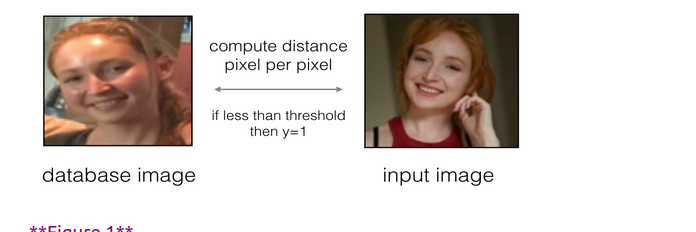


Of course, this algorithm performs really poorly, since the pixel values change dramatically due to variations in lighting, orientation of the person's face, even minor changes in head position, and so on.

We can see that rather than using raw images, we can learn an encoding $$f(img)$$ so that element-wise comparisons of this encodings gives more accurate  judments as to whether 2 pictures are of the same person.


## Encoding the face images into a 128-dim: vector

#### Using an ConvNet to compute the encodings

The FaceNet model takes a lot of data and a long time to train. So following common practice in applied deep learning settings, let's just load weights that someone else has already trained. The network architecture follows the Inception model from Szegedy et al..
The key things about the network

* This neetwork uses 96x96 dim: RGB as its input. Specifically inputs a face image (or batch of `m` images) as a tensor of shape $$(m, n_c,n_H, n_W)$$ = (m, 3, 96, 96)
* It outputs a matrix of shape (m, 128) that encodes each input face image to a 128-dim: vector.



In [ ]:
import os
os.listdir()

['.config',
 'fr_utils.py',
 'andrew.jpg',
 'images.zip',
 'images (1).zip',
 '.ipynb_checkpoints',
 'images',
 '__pycache__',
 'inception_block_v2.py',
 'sample_data']

In [ ]:
import inception_block_v2


In [ ]:
# FRmodel = faceRecoModel(input_shape=(3, 96, 96))
# That was the channel first model , here we use channel last as the keras new model prefer it
FRmodel = inception_block_v2.faceRecoModel(input_shape=(96, 96, 3))
FRmodel.summary()

Model: "FaceNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1_conv     │ (None, 48, 48,    │      9,408 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1_bn       │ (None, 48, 48,    │        256 │ stem_conv1_conv[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1_act      │ (None, 48, 48,    │          0 │ stem_conv1_bn[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 24, 24,    │          0 │ stem_conv1_act[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv2_conv     │ (None, 24, 24,    │      4,096 │ max_pooling2d_7[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv2_bn       │ (None, 24, 24,    │        256 │ stem_conv2_conv[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv2_act      │ (None, 24, 24,    │          0 │ stem_conv2_bn[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv3_conv     │ (None, 24, 24,    │    110,592 │ stem_conv2_act[0… │
│ (Conv2D)            │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv3_bn       │ (None, 24, 24,    │        768 │ stem_conv3_conv[… │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv3_act      │ (None, 24, 24,    │          0 │ stem_conv3_bn[0]… │
│ (Activation)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 12, 12,    │          0 │ stem_conv3_act[0… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3_r… │ (None, 12, 12,    │     18,432 │ max_pooling2d_8[… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5_r… │ (None, 12, 12,    │      3,072 │ max_pooling2d_8[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3_r… │ (None, 12, 12,    │        384 │ inception_3a_3x3… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5_r… │ (None, 12, 12,    │         64 │ inception_3a_5x5… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3_r… │ (None, 12, 12,    │          0 │ inception_3a_3x3

 Total params: 2,558,688 (9.76 MB)

 Trainable params: 2,553,488 (9.74 MB)

 Non-trainable params: 5,200 (20.31 KB)

In [ ]:
print("Total Params:", FRmodel.count_params())

Total Params: 2558688


By using a 128-neuron fully connected layer as its last layer, the model ensures that the output is an encoding vector of size 128. You then use the encodings the compare two face images as follows:


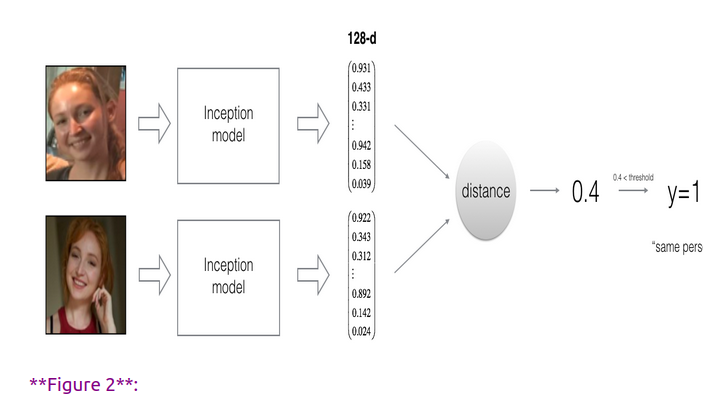

By computing the distance betwween  2 encodings and thresholding we can determine if the 2 pictures represent same person
So an encoding is good one if:
* The encoding of 2 images of the same person are quite similar to each other
* The encodings of 2 images of different persons are different



The triplet loss function formalizes this, and tries to "push" the encodings of two images of the same person (Anchor and Positive) closer together, while "pulling" the encodings of two images of different persons (Anchor, Negative) further apart.

 In the next part, we will call the pictures from left to right: Anchor (A), Positive (P), Negative (N)

 ## The Triplet Loss

 For an image x, we denote the encodings f(x) where f(x) is the fun: computed by the NN

 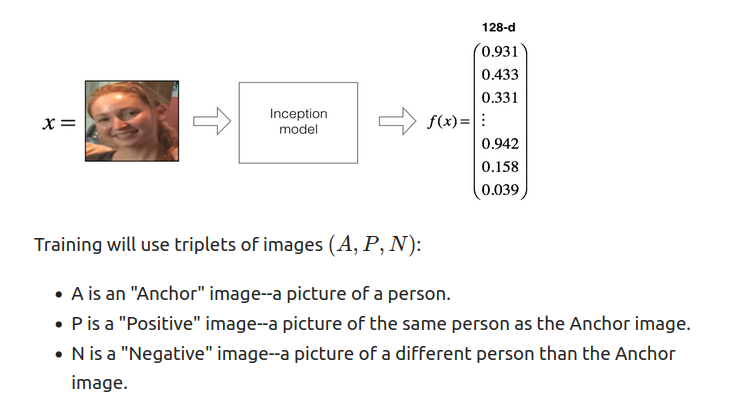

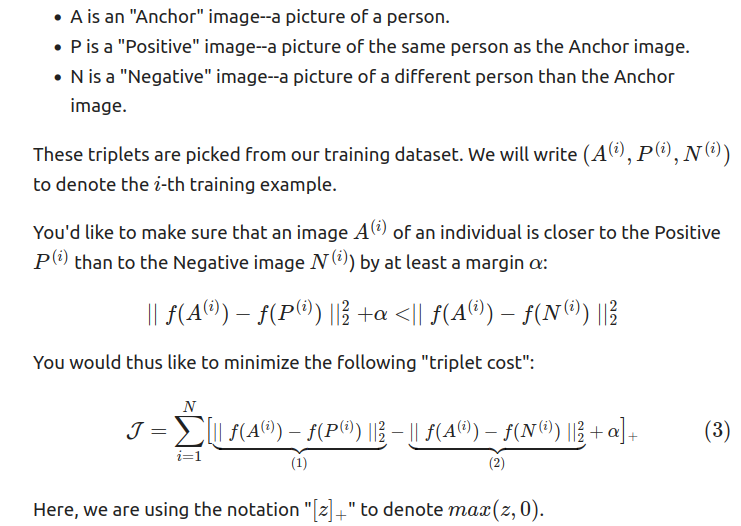

Notes:
* The term (1) is the squared distance between the anchor "A" and the positive "p" for a given triplet; We want this to be small
* The term (2) is the squared distance between the anchor "A" and the negative "N" for a given triplet, you want this to be relatively large, so it thus makes sense to have a minus sign preceding it.
* $$alpha$$  is called the margin. It is a hyperparameter that you should pick manually. We will use  $$a=0.2$$.


Implementing the triplet loss as defined the formula (3) Here are the steps we take

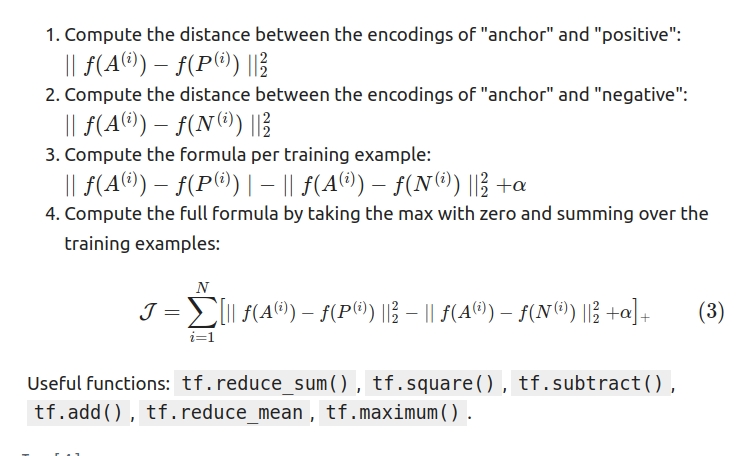

In [ ]:
import tensorflow as tf

def triplet_loss(y_true, y_pred, alpha=0.2):
    """
    Triplet loss for FaceNet (Keras 3 / TF 2.x compatible)

    y_pred: single tensor of shape (batch, 3*embedding_dim)
            concatenation of [anchor, positive, negative]
    """
    embedding_dim = y_pred.shape[-1] // 3

    anchor = y_pred[:, 0:embedding_dim]
    positive = y_pred[:, embedding_dim:2*embedding_dim]
    negative = y_pred[:, 2*embedding_dim:3*embedding_dim]

    # Compute squared distances using TensorFlow functions directly
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

    # Compute basic loss
    basic_loss = pos_dist - neg_dist + alpha

    # Take maximum with 0 and average over batch
    loss = tf.reduce_mean(tf.maximum(basic_loss, 0.0))

    return loss


In [ ]:
import tensorflow as tf

tf.random.set_seed(1)

anchor = tf.random.normal([3, 128], mean=6.0, stddev=0.1, seed=1)
positive = tf.random.normal([3, 128], mean=1.0, stddev=1.0, seed=1)
negative = tf.random.normal([3, 128], mean=3.0, stddev=4.0, seed=1)

y_pred = tf.concat([anchor, positive, negative], axis=1)
y_true = None

loss = triplet_loss(y_true, y_pred)
print("Loss:", loss.numpy())


Loss: 175.75328


## Loading the trained model
FaceNet is trained by minimizing the triplet loss. But since training requires a lot of data and a lot of computation, we won't train it from scratch here. Instead, we load a previously trained model. Load a model using the following cell; this might take a couple of minutes to run.



In [ ]:
def load_weights_from_FaceNet(mode, weights_path="FRModel_weights.h5"):
  """
  Load pretrained FaceNet weights into your model.

  Arguemnts:
    model -- your FRmodel
    weights_path -- path to the .h5 weights file
  """
  import os
  if not os.path.exists(weights_path):
    print(f"Weights file not found: {weights_path}")
    return

  model.load_weigts(weigts_path)
  print("Weights loaded suceesfully")

In [ ]:
# Compile first
FRmodel.compile(optimizer='adam', loss=triplet_loss)

# Load weights (replace with your actual path)
load_weights_from_FaceNet(FRmodel, 'FRmodel_weights.h5')


Weights file not found: FRmodel_weights.h5


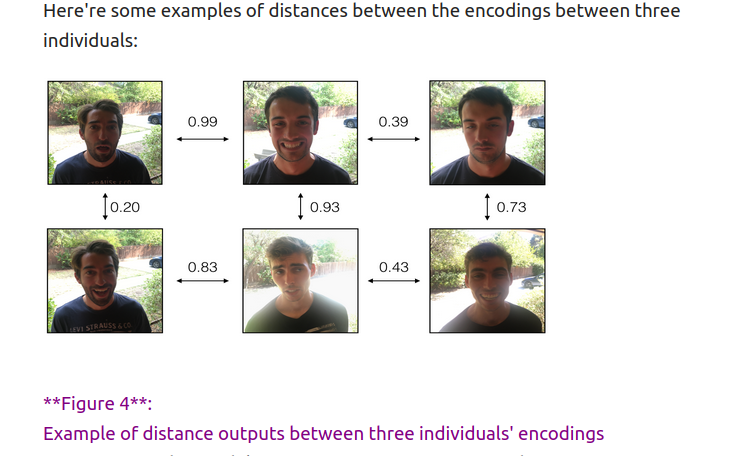

Let we use this model to perform face verification and face recognition



# Applying the model

Back to the Happy House! Residents are living blissfully since you implemented happiness recognition for the house in an earlier assignment.

However, several issues keep coming up: The Happy House became so happy that every happy person in the neighborhood is coming to hang out in your living room. It is getting really crowded, which is having a negative impact on the residents of the house. All these random happy people are also eating all your food.

So, you decide to change the door entry policy, and not just let random happy people enter anymore, even if they are happy! Instead, you'd like to build a Face verification system so as to only let people from a specified list come in. To get admitted, each person has to swipe an ID card (identification card) to identify themselves at the door. The face recognition system then checks that they are who they claim to be.



## Face Verification

Let's build a database containing one encoding vector for each person allowed to enter the happy house. To generate the encoding we use `img_to_encoding(image_path, model)` which basically runs the forward propagation of the model on the specified image.
We run the following code to build the database (represented as a python dictionary). This database maps each person's name to a 128-dimensional encoding of their face.

In [ ]:
from google.colab import files
import zipfile

# Upload the zip
uploaded = files.upload()  # choose images.zip

# Extract it
with zipfile.ZipFile('images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/images')

# Set folder path
image_folder = '/content/images'
import os
print("Files in folder:", os.listdir(image_folder))


KeyboardInterrupt: 

In [ ]:
import zipfile

with zipfile.ZipFile('images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/images')  # extract to this folder


In [ ]:
os.listdir("/content/images/images")


['camera_4.jpg',
 'felix.jpg',
 'triplet_comparison.png',
 'camera_1.jpg',
 'f_x.png',
 'andrew.jpg',
 'camera_2.jpg',
 'pixel_comparison.png',
 'kian.jpg',
 'distance_matrix.png',
 'danielle.png',
 'dan.jpg',
 'tian.jpg',
 'camera_0.jpg',
 'sebastiano.jpg',
 'distance_kiank.png',
 'benoit.jpg',
 'camera_3.jpg',
 'bertrand.jpg',
 'younes.jpg',
 'camera_5.jpg',
 'arnaud.jpg',
 'kevin.jpg',
 'inception_block1a.png']

!

In [ ]:
import cv2
import numpy as np

def preprocess_image(img_path, target_size=(96, 96)):
  img = cv2.imread(img_path)
  if img is None:
    raise ValueError(f"Image not found : {img_path}")

  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  img = cv2.resize(img, target_size)

  img = img / 255.0
  img = (img - 0.5)  * 2.0

  img = np.expand_dims(img, axis=0)
  return img

def img_to_encoding(img_path, model):
  """ Convert an image to a 128-D embeddings using FaceNet"""
  img = preprocess_image(img_path)
  embedding = model.predict(img, verbose=0)  # shape (1, 128)
  return embedding[0]



In [ ]:
database = {}
database["danielle"] = img_to_encoding("/content//images/images/danielle.png", FRmodel)
database["younes"] = img_to_encoding("/content//images/images/younes.jpg", FRmodel)
database["tian"] = img_to_encoding("/content//images/images/tian.jpg", FRmodel)
database["andrew"] = img_to_encoding("/content//images/images/andrew.jpg", FRmodel)
database["kian"] = img_to_encoding("/content//images/images/kian.jpg", FRmodel)
database["dan"] = img_to_encoding("/content//images/images/dan.jpg", FRmodel)
database["sebastiano"] = img_to_encoding("/content//images/images/sebastiano.jpg", FRmodel)
database["bertrand"] = img_to_encoding("/content//images/images/bertrand.jpg", FRmodel)
database["kevin"] = img_to_encoding("/content//images/images/kevin.jpg", FRmodel)
database["felix"] = img_to_encoding("/content//images/images/felix.jpg", FRmodel)
database["benoit"] = img_to_encoding("/content//images/images/benoit.jpg", FRmodel)
database["arnaud"] = img_to_encoding("/content//images/images/arnaud.jpg", FRmodel)


Now, when someone shows up at your front door and swipes their ID card (thus giving you their name), you can look up their encoding in the database, and use it to check if the person standing at the front door matches the name on the ID.



Here we implement verify() function that checks if the front door camera picture (`image_path`) is actually the person called "identity". We take these steps

1. Compute the encodings of the image from image_path
2. Compute the distance about this encodings and the encoding of the identity image stored in the database
3. Open the door if the distance is less than 0.7 else don't open


As presented above, you should use the L2 distance (np.linalg.norm). (Note: In this implementation, compare the L2 distance, not the square of the L2 distance, to the threshold 0.7.)

In [ ]:
def verify(image_path, identity, database, model):
  encodings = img_to_encoding(image_path, model)

  dist = np.linalg.norm(encodings-database[identity])

  if dist < 0.7:
    print("It's " + str(identity) + ', welcome home')
    door_open = True

  else:
    print("It is not " + str(identity) + ", please go away")
    door_open = False
  return dist, door_open


In [ ]:
verify("images/images/camera_0.jpg", "younes", database, FRmodel)


It's younes, welcome home


(np.float32(0.15417685), True)

In [ ]:
verify("images/images/camera_2.jpg", "kian", database, FRmodel)

It's kian, welcome home


(np.float32(0.20976497), True)

## Face Recognition
Your face verification system is mostly working well. But since Kian got his ID card stolen, when he came back to the house that evening he couldn't get in!


To reduce such shenanigans, you'd like to change your face verification system to a face recognition system. This way, no one has to carry an ID card anymore. An authorized person can just walk up to the house, and the front door will unlock for them!

You'll implement a face recognition system that takes as input an image, and figures out if it is one of the authorized persons (and if so, who). Unlike the previous face verification system, we will no longer get a person's name as another input.

We implement `who_is_it`. By following these steps

1. Compute the target encoding of the image from image_path
2. Find the encoding from the database that has smallest distance with the target encoding.
  * Initialize the min_dist variable to a large enough number (100). It will help you keep track of what is the closest encoding to the input's encoding.
  * Loop over the database dictionary's names and encodings. To loop use for (name, db_enc) in database.items().
      * Compute L2 distance between the target "encoding" and the current "encoding" from the database.
      * If this distance is less than the min_dist, then set min_dist to dist, and identity to name.
      



In [ ]:
def who_is_it(image_path, database, model):
  """
      Implements face recognition for the happy house by finding who is the person on the image_path image.
  Returns :
     min_dist -- the minimum dist: between image_path encoding and the  encodings from the database
     idenitiy: --- string , the name prediction for the person on image_path
  """
  encoding = img_to_encoding(image_path, model)


  min_dist = 100
  for (name, db_enc) in database.items():
      dist = np.linalg.norm(encoding-db_enc)
      if dist < min_dist:
        min_dist = dist
        identity = name

  if min_dist > 0.7:
    print("Not in the database")
  else:
    print("it is " + str(identity) + ", the distance is " + str(min_dist))

  return min_dist, identity


In [ ]:
who_is_it("images/images/camera_1.jpg", database, FRmodel)

it is bertrand, the distance is 0.1003862


(np.float32(0.1003862), 'bertrand')

##We can change the `camera_1.png` and see the results


**Summary**
Face verification solves an easier 1:1 matching problem; face recognition addresses a harder 1:K matching problem. - The triplet loss is an effective loss function for training a neural network to learn an encoding of a face image. - The same encoding can be used for verification and recognition. Measuring distances between two images' encodings allows you to determine whether they are pictures of the same person.

